# Perceptual Analysis of Perturbation Strengths

**Experiment:** Compare perturbed images at α = 0.5–1.0 against the corresponding clean/reference images using **PSNR** and **SSIM**.

**Important:** α is the **perturbation strength**. The LoRA is downstream and is not varied in this notebook.

This notebook:
- discovers `alpha_*` folders under `outputs/cloaked/test`
- pairs images by filename stem rather than filesystem order
- validates dimensions and channels
- computes PSNR and SSIM per image
- reports mean, median, SD, and 95% confidence intervals per α
- creates comparative plots
- exports per-image and summary results
- saves reproducibility metadata

SSIM follows the Wang et al.-compatible scikit-image configuration: Gaussian weighting, σ=1.5, sample covariance disabled, and explicit `data_range`. PSNR and SSIM are computed on identically shaped RGB images in the [0,1] range.

In [36]:
# ============================================================
# 1. CONFIGURATION
# ============================================================

from pathlib import Path
import re
import json
import platform
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from scipy import stats
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import skimage

# Project root:
# src/evaluation/perceptual/<this notebook>
PROJECT_ROOT = Path.cwd()

# If the notebook is launched from src/evaluation/perceptual,
# this resolves back to the project root.
if PROJECT_ROOT.name == "perceptual" and PROJECT_ROOT.parent.name == "evaluation":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent.parent

# Explicit paths can be changed here if needed.
REFERENCE_DIR = PROJECT_ROOT / "data" / "test"
PERTURBATION_ROOT = PROJECT_ROOT / "outputs" / "cloaked" / "test"

# Output directory for this evaluation.
EVAL_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "evaluation" / "perceptual"
EVAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Expected perturbation strengths.
EXPECTED_ALPHAS = np.round(np.arange(0.5, 1.01, 0.1), 2)

# Image extensions accepted.
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tif", ".tiff"}

# SSIM settings: Wang et al.-compatible configuration.
SSIM_GAUSSIAN_WEIGHTS = True
SSIM_SIGMA = 1.5
SSIM_USE_SAMPLE_COVARIANCE = False
SSIM_DATA_RANGE = 1.0

# Confidence level.
CI_LEVEL = 0.95

# Whether to resize images.
# False is the strict choice: mismatched dimensions are reported rather
# than silently changing the experimental images.
ALLOW_RESIZE = False

print("Project root:       ", PROJECT_ROOT)
print("Reference directory:", REFERENCE_DIR)
print("Perturbation root:  ", PERTURBATION_ROOT)
print("Evaluation output:  ", EVAL_OUTPUT_DIR)
print("Expected alphas:    ", EXPECTED_ALPHAS.tolist())


Project root:        c:\CSUAP
Reference directory: c:\CSUAP\data\test
Perturbation root:   c:\CSUAP\outputs\cloaked\test
Evaluation output:   c:\CSUAP\outputs\evaluation\perceptual
Expected alphas:     [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]


In [37]:
# ============================================================
# 2. ENVIRONMENT / REPRODUCIBILITY INFORMATION
# ============================================================

metadata = {
    "python_version": sys.version,
    "platform": platform.platform(),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "scikit_image_version": skimage.__version__,
    "project_root": str(PROJECT_ROOT),
    "reference_dir": str(REFERENCE_DIR),
    "perturbation_root": str(PERTURBATION_ROOT),
    "expected_alphas": EXPECTED_ALPHAS.tolist(),
    "metrics": {
        "PSNR": {
            "data_range": 1.0,
            "input_range": "[0, 1]",
        },
        "SSIM": {
            "gaussian_weights": SSIM_GAUSSIAN_WEIGHTS,
            "sigma": SSIM_SIGMA,
            "use_sample_covariance": SSIM_USE_SAMPLE_COVARIANCE,
            "data_range": SSIM_DATA_RANGE,
            "channel_axis": -1,
        },
        "confidence_interval": CI_LEVEL,
        "allow_resize": ALLOW_RESIZE,
    },
}

print(json.dumps(metadata, indent=2))


{
  "python_version": "3.10.6 (tags/v3.10.6:9c7b4bd, Aug  1 2022, 21:53:49) [MSC v.1932 64 bit (AMD64)]",
  "platform": "Windows-10-10.0.26200-SP0",
  "numpy_version": "2.2.6",
  "pandas_version": "2.3.3",
  "scikit_image_version": "0.25.2",
  "project_root": "c:\\CSUAP",
  "reference_dir": "c:\\CSUAP\\data\\test",
  "perturbation_root": "c:\\CSUAP\\outputs\\cloaked\\test",
  "expected_alphas": [
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    1.0
  ],
  "metrics": {
    "PSNR": {
      "data_range": 1.0,
      "input_range": "[0, 1]"
    },
    "SSIM": {
      "gaussian_weights": true,
      "sigma": 1.5,
      "use_sample_covariance": false,
      "data_range": 1.0,
      "channel_axis": -1
    },
    "confidence_interval": 0.95,
    "allow_resize": false
  }
}


In [38]:
# ============================================================
# 3. DISCOVER ALPHA FOLDERS
# ============================================================

if not PERTURBATION_ROOT.exists():
    raise FileNotFoundError(f"Perturbation root not found: {PERTURBATION_ROOT}")

alpha_pattern = re.compile(r"^alpha[_=-]?([0-9]+(?:\.[0-9]+)?)$", re.IGNORECASE)

alpha_dirs = {}

for path in sorted(PERTURBATION_ROOT.iterdir()):
    if not path.is_dir():
        continue

    match = alpha_pattern.match(path.name)
    if match:
        alpha = round(float(match.group(1)), 2)
        alpha_dirs[alpha] = path

if not alpha_dirs:
    raise RuntimeError(
        f"No alpha folders found under {PERTURBATION_ROOT}. "
        "Expected names such as alpha_0.5, alpha_0.6, ..., alpha_1.0."
    )

discovered = sorted(alpha_dirs)

print("Discovered alpha folders:")
for alpha in discovered:
    print(f"  α={alpha:.2f} -> {alpha_dirs[alpha]}")

missing_expected = [
    float(a) for a in EXPECTED_ALPHAS
    if not np.isclose(a, discovered, atol=1e-6).any()
]

if missing_expected:
    print("\nWARNING: expected alpha folders missing:")
    print(missing_expected)


Discovered alpha folders:
  α=0.50 -> c:\CSUAP\outputs\cloaked\test\alpha_0.50
  α=0.60 -> c:\CSUAP\outputs\cloaked\test\alpha_0.60
  α=0.70 -> c:\CSUAP\outputs\cloaked\test\alpha_0.70
  α=0.80 -> c:\CSUAP\outputs\cloaked\test\alpha_0.80
  α=0.90 -> c:\CSUAP\outputs\cloaked\test\alpha_0.90
  α=1.00 -> c:\CSUAP\outputs\cloaked\test\alpha_1.00


In [39]:
# ============================================================
# 4. LOCATE REFERENCE IMAGES
# ============================================================

if not REFERENCE_DIR.exists():
    raise FileNotFoundError(
        f"Reference directory does not exist: {REFERENCE_DIR}\n"
        "Set REFERENCE_DIR in the configuration cell to the clean/original "
        "test-image directory."
    )

def image_files(directory):
    return sorted(
        p for p in Path(directory).rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )

reference_files = image_files(REFERENCE_DIR)

if not reference_files:
    raise RuntimeError(f"No reference images found in {REFERENCE_DIR}")

reference_by_stem = {}

for path in reference_files:
    stem = path.stem
    if stem in reference_by_stem:
        raise RuntimeError(
            f"Duplicate reference stem detected: {stem}\n"
            f"  {reference_by_stem[stem]}\n"
            f"  {path}"
        )
    reference_by_stem[stem] = path

print(f"Reference images found: {len(reference_by_stem)}")
print("Example references:")
for p in reference_files[:10]:
    print(" ", p)


Reference images found: 31
Example references:
  c:\CSUAP\data\test\4610.jpg
  c:\CSUAP\data\test\4761.jpg
  c:\CSUAP\data\test\5e03b897-22d4-4a14-a22e-ddcd38187020.jpg
  c:\CSUAP\data\test\9b03a6af-302f-4350-8f3d-f68c820cbb7f.jpg
  c:\CSUAP\data\test\a7f65312-8df7-4bec-ba76-4adba2196a07-1_all_2610.jpg
  c:\CSUAP\data\test\a7f65312-8df7-4bec-ba76-4adba2196a07-1_all_7407.jpg
  c:\CSUAP\data\test\d23ff9e4-b149-48a8-aed2-f922a0508488.jpg
  c:\CSUAP\data\test\IMG20250822231100.jpg
  c:\CSUAP\data\test\IMG20260108150419.jpg
  c:\CSUAP\data\test\IMG20260412080840.jpg


In [40]:
# ============================================================
# 5. IMAGE LOADING / STANDARDIZATION
# ============================================================

def load_rgb_float(path):
    """Load an image as RGB float32 in [0, 1]."""
    with Image.open(path) as im:
        im = im.convert("RGB")
        arr = np.asarray(im, dtype=np.float32) / 255.0
    return arr

def validate_pair_shapes(reference, test, reference_path, test_path):
    if reference.shape != test.shape:
        if not ALLOW_RESIZE:
            raise ValueError(
                "Shape mismatch. Strict evaluation refuses to resize images:\n"
                f"  Reference: {reference_path} -> {reference.shape}\n"
                f"  Test:      {test_path} -> {test.shape}"
            )

def safe_ci(values, confidence=0.95):
    values = np.asarray(values, dtype=np.float64)
    n = len(values)

    if n < 2:
        return np.nan, np.nan

    mean = np.mean(values)
    sem = stats.sem(values)
    t_critical = stats.t.ppf((1 + confidence) / 2, df=n - 1)

    return mean - t_critical * sem, mean + t_critical * sem


In [41]:
# ============================================================
# 6. PAIR VALIDATION
# ============================================================

pair_records = []
validation_records = []

manifest_path = PERTURBATION_ROOT / "manifest.json"
manifest_by_alpha = {}

if manifest_path.exists():
    with open(manifest_path, "r", encoding="utf-8") as f:
        manifest_records = json.load(f)

    for item in manifest_records:
        alpha = round(float(item["alpha"]), 2)
        manifest_by_alpha.setdefault(alpha, []).append(item)

for alpha in discovered:
    alpha_dir = alpha_dirs[alpha]

    if alpha in manifest_by_alpha:
        for item in manifest_by_alpha[alpha]:
            source_stem = Path(item["source_image"]).stem
            reference_path = reference_by_stem.get(source_stem)
            test_path = PERTURBATION_ROOT / item["cloaked_image"]

            if reference_path is None:
                validation_records.append({
                    "alpha": alpha,
                    "status": "missing_reference",
                    "stem": source_stem,
                    "reference": item["source_image"],
                    "test": str(test_path),
                })
            elif not test_path.exists():
                validation_records.append({
                    "alpha": alpha,
                    "status": "missing_test",
                    "stem": source_stem,
                    "reference": str(reference_path),
                    "test": str(test_path),
                })
            else:
                pair_records.append({
                    "alpha": alpha,
                    "stem": source_stem,
                    "reference_path": reference_path,
                    "test_path": test_path,
                })
        continue

    # Cloaked filenames from apply_perturbation.py follow the pattern
    # "{source_stem}_{mode}.png" (e.g. img1_resize.png), so a raw stem
    # comparison against the reference's "img1" would never match. Strip
    # a trailing "_resize" or "_tile" suffix (the two modes actually
    # produced) before comparing, so this fallback path works correctly
    # even without a manifest.json to drive pairing directly.
    KNOWN_MODE_SUFFIXES = ("_resize", "_tile")

    def strip_mode_suffix(stem):
        for suffix in KNOWN_MODE_SUFFIXES:
            if stem.endswith(suffix):
                return stem[: -len(suffix)]
        return stem

    test_files = image_files(alpha_dir)
    test_by_stem = {}

    for path in test_files:
        stem = strip_mode_suffix(path.stem)
        if stem in test_by_stem:
            validation_records.append({
                "alpha": alpha,
                "status": "duplicate_test_stem",
                "stem": stem,
                "reference": str(reference_by_stem.get(stem, "")),
                "test": str(path),
            })
        else:
            test_by_stem[stem] = path

    common = sorted(set(reference_by_stem) & set(test_by_stem))
    missing_test = sorted(set(reference_by_stem) - set(test_by_stem))
    extra_test = sorted(set(test_by_stem) - set(reference_by_stem))

    for stem in common:
        pair_records.append({
            "alpha": alpha,
            "stem": stem,
            "reference_path": reference_by_stem[stem],
            "test_path": test_by_stem[stem],
        })

    for stem in missing_test:
        validation_records.append({
            "alpha": alpha,
            "status": "missing_test",
            "stem": stem,
            "reference": str(reference_by_stem[stem]),
            "test": "",
        })

    for stem in extra_test:
        validation_records.append({
            "alpha": alpha,
            "status": "extra_test",
            "stem": stem,
            "reference": "",
            "test": str(test_by_stem[stem]),
        })

validation_df = pd.DataFrame(validation_records)

pair_counts = (
    pd.DataFrame(pair_records, columns=["alpha", "stem", "reference_path", "test_path"])
    .groupby("alpha")
    .size()
    .rename("paired_images")
    .reset_index()
)

print("Pairing summary:")
display(pair_counts)

if not validation_df.empty:
    print("\nValidation issues:")
    display(validation_df)
else:
    print("\nNo pairing issues detected.")

if not pair_records:
    raise FileNotFoundError(
        "No valid image pairs were found. Check the validation table and ensure "
        f"the cloaked image files listed in {manifest_path} exist."
    )

Pairing summary:


,alpha,paired_images
0,0.5,30
1,0.6,30
2,0.7,30
3,0.8,30
4,0.9,30
5,1.0,30



No pairing issues detected.


In [42]:
# ============================================================
# 7. COMPUTE PSNR + SSIM PER IMAGE
# ============================================================

results = []
errors = []

for record in pair_records:
    alpha = record["alpha"]
    stem = record["stem"]
    reference_path = record["reference_path"]
    test_path = record["test_path"]

    try:
        reference = load_rgb_float(reference_path)
        test = load_rgb_float(test_path)

        validate_pair_shapes(
            reference,
            test,
            reference_path,
            test_path
        )

        # PSNR uses the fixed, explicit [0,1] data range.
        psnr = peak_signal_noise_ratio(
            reference,
            test,
            data_range=1.0
        )

        # SSIM uses the Wang et al.-compatible configuration.
        ssim = structural_similarity(
            reference,
            test,
            data_range=SSIM_DATA_RANGE,
            channel_axis=-1,
            gaussian_weights=SSIM_GAUSSIAN_WEIGHTS,
            sigma=SSIM_SIGMA,
            use_sample_covariance=SSIM_USE_SAMPLE_COVARIANCE,
        )

        results.append({
            "alpha": alpha,
            "image_id": stem,
            "reference_path": str(reference_path),
            "test_path": str(test_path),
            "height": reference.shape[0],
            "width": reference.shape[1],
            "channels": reference.shape[2],
            "psnr_db": float(psnr),
            "ssim": float(ssim),
            "status": "ok",
        })

    except Exception as exc:
        errors.append({
            "alpha": alpha,
            "image_id": stem,
            "reference_path": str(reference_path),
            "test_path": str(test_path),
            "status": "error",
            "error": repr(exc),
        })

results_df = pd.DataFrame(results)
errors_df = pd.DataFrame(errors)

print(f"Successful comparisons: {len(results_df)}")
print(f"Failed comparisons:     {len(errors_df)}")

if not errors_df.empty:
    display(errors_df)

if results_df.empty:
    raise RuntimeError("No valid image comparisons were produced.")

display(results_df.head())

Successful comparisons: 180
Failed comparisons:     0


,alpha,image_id,reference_path,test_path,height,width,channels,psnr_db,ssim,status
0,0.5,4610,c:\CSUAP\data\test\4610.jpg,c:\CSUAP\outputs\cloaked\test\alpha_0.50\img1.png,4096,3072,3,35.038188,0.988643,ok
1,0.5,4761,c:\CSUAP\data\test\4761.jpg,c:\CSUAP\outputs\cloaked\test\alpha_0.50\img2.png,4032,2688,3,34.958183,0.976362,ok
2,0.5,5e03b897-22d4-4a14-a22e-ddcd38187020,c:\CSUAP\data\test\5e03b897-22d4-4a14-a22e-ddc...,c:\CSUAP\outputs\cloaked\test\alpha_0.50\img3.png,729,581,3,34.984472,0.918285,ok
3,0.5,9b03a6af-302f-4350-8f3d-f68c820cbb7f,c:\CSUAP\data\test\9b03a6af-302f-4350-8f3d-f68...,c:\CSUAP\outputs\cloaked\test\alpha_0.50\img4.png,1312,982,3,35.004249,0.947612,ok
4,0.5,a7f65312-8df7-4bec-ba76-4adba2196a07-1_all_2610,c:\CSUAP\data\test\a7f65312-8df7-4bec-ba76-4ad...,c:\CSUAP\outputs\cloaked\test\alpha_0.50\img5.png,3280,2464,3,35.067194,0.987363,ok


In [43]:
# ============================================================
# 8. STATISTICAL SUMMARY BY ALPHA
# ============================================================

def summarize_metric(group, column):
    values = group[column].dropna().to_numpy(dtype=float)
    n = len(values)

    mean = np.mean(values)
    median = np.median(values)
    std = np.std(values, ddof=1) if n >= 2 else np.nan
    ci_low, ci_high = safe_ci(values, CI_LEVEL)

    return {
        f"{column}_mean": mean,
        f"{column}_median": median,
        f"{column}_std": std,
        f"{column}_ci95_low": ci_low,
        f"{column}_ci95_high": ci_high,
    }

summary_records = []

for alpha, group in results_df.groupby("alpha", sort=True):
    row = {
        "alpha": alpha,
        "n": len(group),
    }

    row.update(summarize_metric(group, "psnr_db"))
    row.update(summarize_metric(group, "ssim"))

    summary_records.append(row)

summary_df = pd.DataFrame(summary_records).sort_values("alpha")

print("Per-alpha summary:")
display(summary_df)


Per-alpha summary:


,alpha,n,psnr_db_mean,psnr_db_median,psnr_db_std,psnr_db_ci95_low,psnr_db_ci95_high,ssim_mean,ssim_median,ssim_std,ssim_ci95_low,ssim_ci95_high
0,0.5,30,35.000889,34.966430,0.083066,34.969872,35.031906,0.969879,0.972349,0.017452,0.963363,0.976396
1,0.6,30,33.078040,33.042400,0.085667,33.046052,33.110029,0.955716,0.958786,0.024854,0.946435,0.964996
2,0.7,30,31.840521,31.804637,0.088216,31.807581,31.873461,0.942833,0.946219,0.031010,0.931254,0.954412
3,0.8,30,30.792873,30.756838,0.090084,30.759235,30.826511,0.929413,0.932979,0.036997,0.915598,0.943228
4,0.9,30,29.864538,29.828655,0.091657,29.830313,29.898763,0.915332,0.919020,0.042860,0.899327,0.931336
5,1.0,30,28.748832,28.716194,0.093791,28.713809,28.783854,0.896658,0.900398,0.050376,0.877848,0.915469


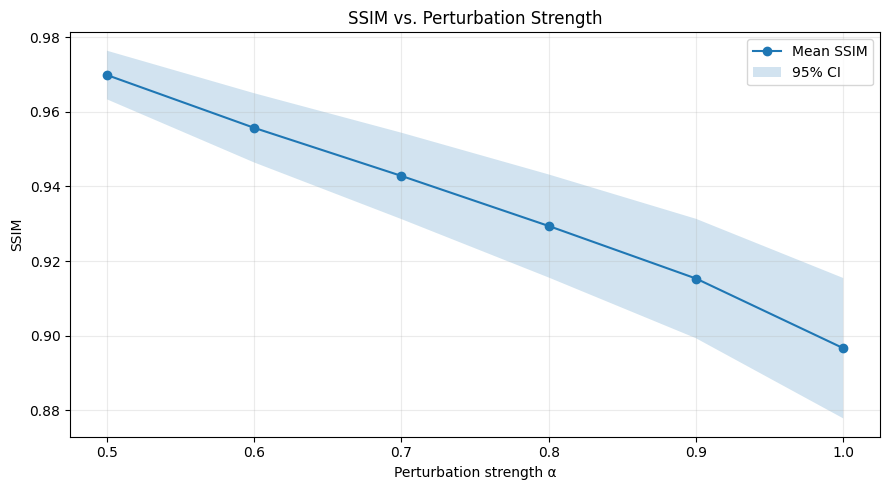

Saved: c:\CSUAP\outputs\evaluation\perceptual\ssim_vs_alpha.png


In [44]:
# ============================================================
# 9. PLOTS: MEAN SSIM WITH 95% CI
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

x = summary_df["alpha"].to_numpy()
y = summary_df["ssim_mean"].to_numpy()

lower = summary_df["ssim_ci95_low"].to_numpy()
upper = summary_df["ssim_ci95_high"].to_numpy()

ax.plot(x, y, marker="o", label="Mean SSIM")
ax.fill_between(x, lower, upper, alpha=0.2, label="95% CI")

ax.set_xlabel("Perturbation strength α")
ax.set_ylabel("SSIM")
ax.set_title("SSIM vs. Perturbation Strength")
ax.set_xticks(x)
ax.grid(True, alpha=0.25)
ax.legend()

plt.tight_layout()

ssim_plot_path = EVAL_OUTPUT_DIR / "ssim_vs_alpha.png"
plt.savefig(ssim_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {ssim_plot_path}")


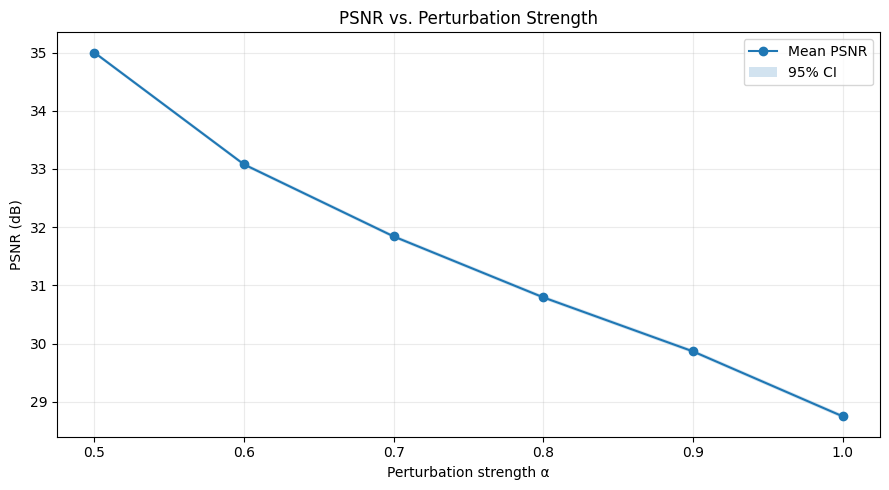

Saved: c:\CSUAP\outputs\evaluation\perceptual\psnr_vs_alpha.png


In [45]:
# ============================================================
# 10. PLOTS: MEAN PSNR WITH 95% CI
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

x = summary_df["alpha"].to_numpy()
y = summary_df["psnr_db_mean"].to_numpy()

lower = summary_df["psnr_db_ci95_low"].to_numpy()
upper = summary_df["psnr_db_ci95_high"].to_numpy()

ax.plot(x, y, marker="o", label="Mean PSNR")
ax.fill_between(x, lower, upper, alpha=0.2, label="95% CI")

ax.set_xlabel("Perturbation strength α")
ax.set_ylabel("PSNR (dB)")
ax.set_title("PSNR vs. Perturbation Strength")
ax.set_xticks(x)
ax.grid(True, alpha=0.25)
ax.legend()

plt.tight_layout()

psnr_plot_path = EVAL_OUTPUT_DIR / "psnr_vs_alpha.png"
plt.savefig(psnr_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {psnr_plot_path}")


C:\Users\LOQ\AppData\Local\Temp\ipykernel_8696\2143805036.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(ssim_data, labels=ssim_labels, showmeans=True)


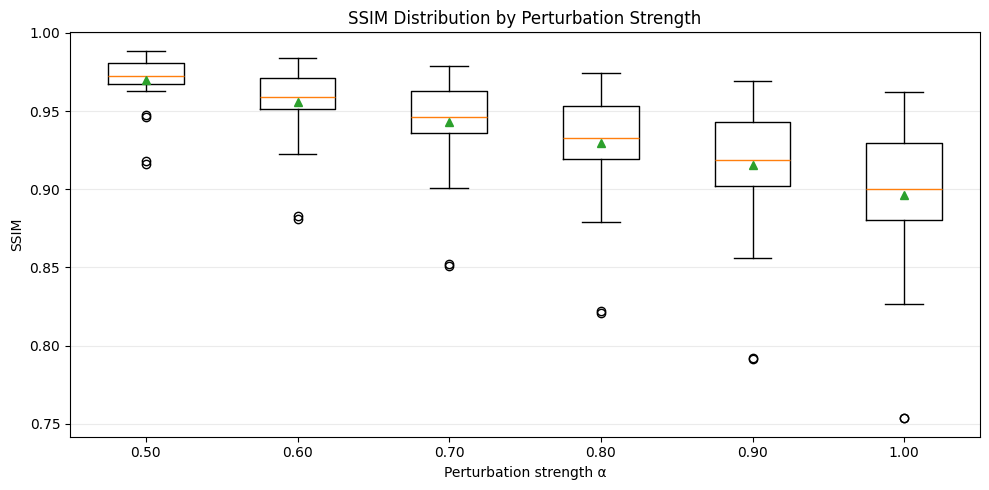

Saved: c:\CSUAP\outputs\evaluation\perceptual\ssim_distribution.png


In [46]:
# ============================================================
# 11. DISTRIBUTION PLOTS
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ssim_data = [
    results_df.loc[results_df["alpha"] == alpha, "ssim"].to_numpy()
    for alpha in sorted(results_df["alpha"].unique())
]

ssim_labels = [
    f"{alpha:.2f}" for alpha in sorted(results_df["alpha"].unique())
]

ax.boxplot(ssim_data, labels=ssim_labels, showmeans=True)
ax.set_xlabel("Perturbation strength α")
ax.set_ylabel("SSIM")
ax.set_title("SSIM Distribution by Perturbation Strength")
ax.grid(True, axis="y", alpha=0.25)

plt.tight_layout()

path = EVAL_OUTPUT_DIR / "ssim_distribution.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


C:\Users\LOQ\AppData\Local\Temp\ipykernel_8696\1008501999.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(psnr_data, labels=psnr_labels, showmeans=True)


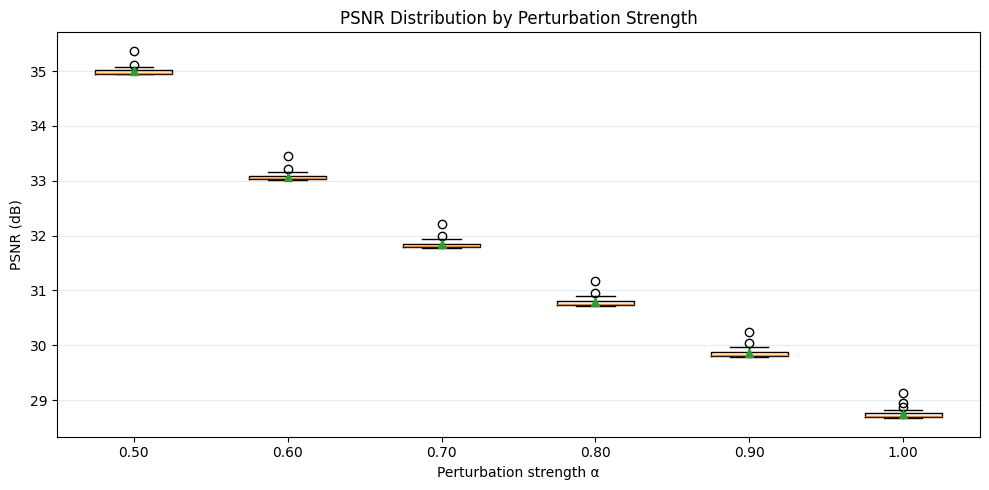

Saved: c:\CSUAP\outputs\evaluation\perceptual\psnr_distribution.png


In [47]:
# ============================================================
# 12. PSNR DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

psnr_data = [
    results_df.loc[results_df["alpha"] == alpha, "psnr_db"].to_numpy()
    for alpha in sorted(results_df["alpha"].unique())
]

psnr_labels = [
    f"{alpha:.2f}" for alpha in sorted(results_df["alpha"].unique())
]

ax.boxplot(psnr_data, labels=psnr_labels, showmeans=True)
ax.set_xlabel("Perturbation strength α")
ax.set_ylabel("PSNR (dB)")
ax.set_title("PSNR Distribution by Perturbation Strength")
ax.grid(True, axis="y", alpha=0.25)

plt.tight_layout()

path = EVAL_OUTPUT_DIR / "psnr_distribution.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


In [48]:
# ============================================================
# 13. RANK ALPHAS
# ============================================================

ranking = summary_df[
    [
        "alpha",
        "n",
        "ssim_mean",
        "ssim_median",
        "ssim_std",
        "ssim_ci95_low",
        "ssim_ci95_high",
        "psnr_db_mean",
        "psnr_db_median",
        "psnr_db_std",
        "psnr_db_ci95_low",
        "psnr_db_ci95_high",
    ]
].copy()

ranking["ssim_rank"] = ranking["ssim_mean"].rank(
    ascending=False,
    method="min"
).astype(int)

ranking["psnr_rank"] = ranking["psnr_db_mean"].rank(
    ascending=False,
    method="min"
).astype(int)

ranking["combined_rank"] = (
    ranking["ssim_rank"] + ranking["psnr_rank"]
)

ranking = ranking.sort_values(
    ["combined_rank", "ssim_rank", "psnr_rank", "alpha"]
)

print("Alpha ranking:")
display(ranking)

best_ssim = summary_df.loc[
    summary_df["ssim_mean"].idxmax()
]

best_psnr = summary_df.loc[
    summary_df["psnr_db_mean"].idxmax()
]

print(
    f"Highest mean SSIM: α={best_ssim['alpha']:.2f} "
    f"({best_ssim['ssim_mean']:.6f})"
)

print(
    f"Highest mean PSNR: α={best_psnr['alpha']:.2f} "
    f"({best_psnr['psnr_db_mean']:.4f} dB)"
)


Alpha ranking:


,alpha,n,ssim_mean,ssim_median,ssim_std,ssim_ci95_low,ssim_ci95_high,psnr_db_mean,psnr_db_median,psnr_db_std,psnr_db_ci95_low,psnr_db_ci95_high,ssim_rank,psnr_rank,combined_rank
0,0.5,30,0.969879,0.972349,0.017452,0.963363,0.976396,35.000889,34.966430,0.083066,34.969872,35.031906,1,1,2
1,0.6,30,0.955716,0.958786,0.024854,0.946435,0.964996,33.078040,33.042400,0.085667,33.046052,33.110029,2,2,4
2,0.7,30,0.942833,0.946219,0.031010,0.931254,0.954412,31.840521,31.804637,0.088216,31.807581,31.873461,3,3,6
3,0.8,30,0.929413,0.932979,0.036997,0.915598,0.943228,30.792873,30.756838,0.090084,30.759235,30.826511,4,4,8
4,0.9,30,0.915332,0.919020,0.042860,0.899327,0.931336,29.864538,29.828655,0.091657,29.830313,29.898763,5,5,10
5,1.0,30,0.896658,0.900398,0.050376,0.877848,0.915469,28.748832,28.716194,0.093791,28.713809,28.783854,6,6,12


Highest mean SSIM: α=0.50 (0.969879)
Highest mean PSNR: α=0.50 (35.0009 dB)


In [49]:
# ============================================================
# 14. EXPORT RESULTS
# ============================================================

per_image_csv = EVAL_OUTPUT_DIR / "per_image_metrics.csv"
summary_csv = EVAL_OUTPUT_DIR / "alpha_summary.csv"
validation_csv = EVAL_OUTPUT_DIR / "validation_issues.csv"
errors_csv = EVAL_OUTPUT_DIR / "metric_errors.csv"
metadata_json = EVAL_OUTPUT_DIR / "evaluation_metadata.json"
excel_path = EVAL_OUTPUT_DIR / "perceptual_analysis.xlsx"

results_df.to_csv(per_image_csv, index=False)
summary_df.to_csv(summary_csv, index=False)
validation_df.to_csv(validation_csv, index=False)
errors_df.to_csv(errors_csv, index=False)

with open(metadata_json, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    results_df.to_excel(writer, sheet_name="per_image_metrics", index=False)
    summary_df.to_excel(writer, sheet_name="alpha_summary", index=False)
    ranking.to_excel(writer, sheet_name="alpha_ranking", index=False)
    validation_df.to_excel(writer, sheet_name="validation", index=False)
    errors_df.to_excel(writer, sheet_name="errors", index=False)

print("Exported:")
for path in [
    per_image_csv,
    summary_csv,
    validation_csv,
    errors_csv,
    metadata_json,
    excel_path,
]:
    print(" ", path)


Exported:
  c:\CSUAP\outputs\evaluation\perceptual\per_image_metrics.csv
  c:\CSUAP\outputs\evaluation\perceptual\alpha_summary.csv
  c:\CSUAP\outputs\evaluation\perceptual\validation_issues.csv
  c:\CSUAP\outputs\evaluation\perceptual\metric_errors.csv
  c:\CSUAP\outputs\evaluation\perceptual\evaluation_metadata.json
  c:\CSUAP\outputs\evaluation\perceptual\perceptual_analysis.xlsx


## Interpretation

For the perturbation experiment, **higher SSIM and higher PSNR indicate greater fidelity to the clean/reference image**.

- **SSIM** emphasizes structural similarity and is bounded near 1 for identical images.
- **PSNR** is reported in dB; higher values indicate lower reconstruction error.

These metrics should be interpreted as **fidelity measures**, not as a complete measure of perceptual quality or semantic utility. The notebook therefore reports both metrics rather than selecting an alpha from only one measure.

The alpha that minimizes perceptual change is the one with the highest mean SSIM/PSNR, subject to the experimental objective. If the research question instead seeks a balance between perturbation strength and fidelity, the exported per-alpha results can be used for a subsequent trade-off analysis.